# Training -- Ohashi ResNet50 Baseline on LDCT-IQAC

## Objective

Train the **first baseline** from:

> Ohashi et al., *"Development of a No-Reference CT Image Quality Assessment
> Method Using RadImageNet Pre-trained Deep Learning Models."*

Specifically: a **RadImageNet-pretrained ResNet50**, with its classification
head replaced by `Dropout -> Dense(1) -> Sigmoid`, trained as a CT image
quality **regressor** on the **LDCT-IQAC** dataset.

**Scope guardrails for this notebook:**
- No project novelty is implemented here; no InceptionResNetV2.
- All architecture/data/preprocessing/training code lives in the `ct_iqa`
  package (`src/ct_iqa/`) and is only **imported** below -- this notebook is
  an experiment runner, not an implementation surface (see
  `docs/internal/repository_architecture_audit.md`, Rules 1-3).
- Held-out test-set evaluation is a **separate notebook**
  (`notebooks/04_evaluation/01_test_set_evaluation.ipynb`) that loads this
  run's checkpoint from `experiments/001_resnet50_baseline/checkpoint/` --
  it does not rely on this notebook's in-memory state.

**Known deviations from the paper/task brief** (see
`docs/replication/deviations.md` for the full list): LDCT-IQAC images are
TIFF (not PNG); the regression target is LDCT-IQAC's radiologist quality
score (not the paper's VIF metric); no synthetic degradation pipeline is
used (LDCT-IQAC already varies in real quality); the Dropout probability is
not specified by the paper and is an explicit, documented choice here.

## Configuration

Loaded from `configs/dataset.yaml` + `configs/preprocessing.yaml` +
`configs/model.yaml` + `configs/training.yaml` via
`ExperimentConfig.from_yaml_files()` -- this is the single authoritative
configuration source (see `src/ct_iqa/config.py`); no dataset/hyperparameter
values are hardcoded separately in this notebook.

`configs/model.yaml`'s `radimagenet_weights_path` points at a converted,
**verified-compatible** RadImageNet checkpoint (265/318 backbone keys
matched, 0 unexpected -- see
`weights/pretrained/radimagenet/resnet50/README.md`). That file is
gitignored (large binary) -- if it isn't present on this machine, the load
below will raise `FileNotFoundError` rather than silently falling back to
ImageNet weights or continuing with a random backbone. To deliberately run
without it, pass `radimagenet_weights_path=None` when building `config`
below.

In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd()
_repo_root = _cwd if (_cwd / "data").exists() else _cwd.parent.parent  # notebooks/03_training/ -> repo root
os.chdir(_repo_root)
if str(_repo_root / "src") not in sys.path:
    sys.path.insert(0, str(_repo_root / "src"))  # only needed until `pip install -e .` is run
print(f"repo root: {_repo_root}")

repo root: C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment


In [2]:
import json
import logging

import matplotlib.pyplot as plt
import torch

import platform

from ct_iqa.config import ExperimentConfig
from ct_iqa.data.ldct_iqac import LDCTIQACDataset, SCORE_MIN, SCORE_MAX
from ct_iqa.data.loader import build_dataloaders, build_test_dataloader
from ct_iqa.models.ohashi_resnet50 import OhashiResNet50, INPUT_SIZE
from ct_iqa.training.trainer import evaluate_loader, train, train_one_step
from ct_iqa.training.losses import build_loss
from ct_iqa.training.optimizers import build_optimizer
from ct_iqa.utils.seed import set_seed

logging.basicConfig(level=logging.INFO)
%matplotlib inline

print(f"python : {platform.python_version()}")
print(f"torch  : {torch.__version__}  cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"gpu    : {torch.cuda.get_device_name(0)}")

python : 3.10.20
torch  : 2.14.0+cpu  cuda available: False


In [3]:
config = ExperimentConfig.from_yaml_files(
    device="cuda" if torch.cuda.is_available() else "cpu",
)
set_seed(config.seed)
print(f"seed            : {config.seed}")
print(f"device          : {config.device}")
print(f"experiment_dir  : {config.experiment_dir}")
print(f"checkpoint_dir  : {config.checkpoint_dir}")
config

seed            : 42
device          : cpu
experiment_dir  : experiments/001_resnet50_baseline
checkpoint_dir  : experiments\001_resnet50_baseline\checkpoint


ExperimentConfig(seed=42, batch_size=64, epochs=30, learning_rate=0.001, optimizer='adam', loss='mse', image_size=224, selection_metric='plcc', dropout_p=0.5, in_channels=1, train_image_dir='data/raw/ldct_iqac/train/image', train_json_path='data/labels/ldct_iqac/train.json', test_image_dir='data/raw/ldct_iqac/test/images', test_json_path='data/labels/ldct_iqac/test.json', dataset_name='ldct_iqac', architecture='ohashi_resnet50', val_fraction=0.1, radimagenet_weights_path='weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt', experiment_dir='experiments/001_resnet50_baseline', device='cpu')

## Data

Dataset construction itself performs the audit: it fails loudly if any
image has no label, any label has no image, the JSON is malformed, or an
unsupported image mode is encountered. The validation split is created
**only from the training set** (`ct_iqa.data.splits.train_val_split`,
`val_fraction` from `configs/dataset.yaml`) -- the official test set is
never used for model selection; `build_test_dataloader` is a separate,
independent loader used only in the evaluation notebook.

In [4]:
for p in [config.train_image_dir, config.train_json_path, config.test_image_dir, config.test_json_path]:
    assert Path(p).exists(), f"missing: {p}"

train_dataset = LDCTIQACDataset(config.train_image_dir, config.train_json_path, image_size=config.image_size)
test_dataset = LDCTIQACDataset(config.test_image_dir, config.test_json_path, image_size=config.image_size)

print(f"training samples: {len(train_dataset)}")
print(f"testing samples : {len(test_dataset)}")
print(f"score range (dataset constants): [{SCORE_MIN}, {SCORE_MAX}]")
print(f"observed train score range: [{min(train_dataset.raw_scores)}, {max(train_dataset.raw_scores)}]")

training samples: 1000
testing samples : 300
score range (dataset constants): [0.0, 4.0]
observed train score range: [0.0, 4.0]


In [5]:
train_loader, val_loader = build_dataloaders(config)
test_loader = build_test_dataloader(config)  # held out; not used again until the evaluation notebook

print(f"train batches: {len(train_loader)}  ({len(train_loader.dataset)} samples)")
print(f"val batches  : {len(val_loader)}  ({len(val_loader.dataset)} samples)")

train batches: 15  (900 samples)
val batches  : 2  (100 samples)


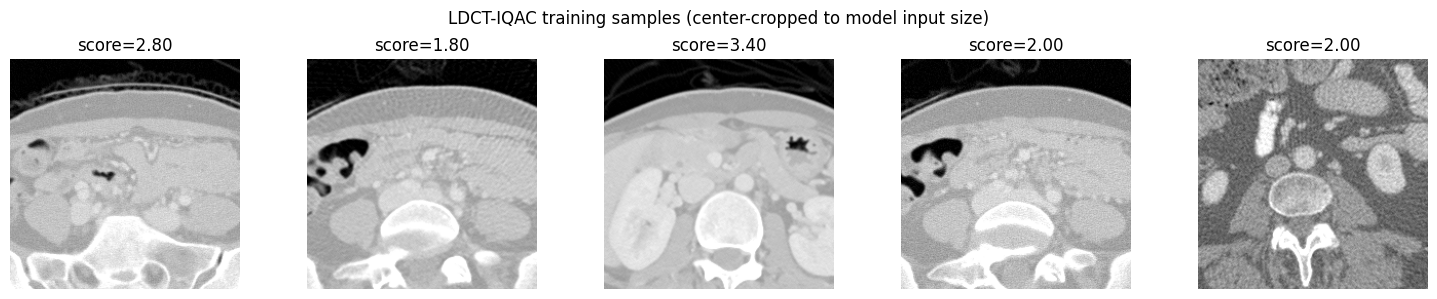

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    image, score = train_dataset[i]
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"score={float(score):.2f}")
    ax.axis("off")
plt.suptitle("LDCT-IQAC training samples (center-cropped to model input size)")
plt.tight_layout()
plt.show()

## Model

`OhashiResNet50` = `ResNet50Backbone` (from-scratch standard ResNet50,
since `torchvision` is not installed in this environment) + `Dropout` +
`Dense(1)` + `Sigmoid`, per the Ohashi paper's stated modification. The
architecture is defined entirely in `src/ct_iqa/models/` -- this notebook
only instantiates and configures it.

In [7]:
model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)
model.to(config.device)

if config.radimagenet_weights_path is not None:
    report = model.load_radimagenet_weights(config.radimagenet_weights_path)
    print(report.summary())
else:
    print("radimagenet_weights_path is None -- backbone remains randomly initialized.")

total_params = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total_params:,}")

INFO:ct_iqa.models.ohashi_resnet50:RadImageNet weights loaded from weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt: 265 matched, 53 missing, 0 unexpected. 53 num_batches_tracked counters left at 0 (expected -- not learned parameters).


RadImageNet weights loaded from weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt: 265 matched, 53 missing, 0 unexpected. 53 num_batches_tracked counters left at 0 (expected -- not learned parameters).
total parameters: 23,510,081


In [8]:
dummy_input = torch.randn(2, config.in_channels, INPUT_SIZE, INPUT_SIZE).to(config.device)
model.eval()
with torch.no_grad():
    dummy_output = model(dummy_input)
assert dummy_output.shape == (2,)
print(f"input shape : {tuple(dummy_input.shape)}  output shape: {tuple(dummy_output.shape)}  shapes OK.")

input shape : (2, 1, 224, 224)  output shape: (2,)  shapes OK.


## Smoke test

Before committing to any real training time, verify the full
`real image -> preprocessing -> DataLoader -> RadImageNet ResNet50 ->
Ohashi head -> prediction -> loss -> backward() -> optimizer.step()` path
on a couple of REAL batches and a couple of real optimizer steps -- this is
NOT the full training run (that is separately gated below by
`RUN_FULL_TRAINING`), just a correctness check that the pipeline actually
works end to end before spending 30 epochs' worth of compute on it.

In [9]:
SMOKE_TEST_STEPS = 2

smoke_optimizer = build_optimizer(model, config)
smoke_criterion = build_loss(config)

before = {name: p.detach().clone() for name, p in model.named_parameters()}
losses = []
for step, batch in zip(range(SMOKE_TEST_STEPS), train_loader):
    images, raw_scores = batch
    assert torch.isfinite(images).all(), "non-finite values in a real preprocessed batch"
    loss = train_one_step(model, batch, smoke_optimizer, smoke_criterion, device=config.device)
    assert loss == loss and loss != float("inf"), f"non-finite loss at smoke step {step}: {loss}"
    losses.append(loss)
    print(f"smoke step {step}: batch={tuple(images.shape)}  loss={loss:.6f}")

grads_exist = all(p.grad is not None for p in model.parameters())
changed = [name for name, p0 in before.items() if not torch.equal(p0, dict(model.named_parameters())[name])]

model.eval()
with torch.no_grad():
    sanity_images, _ = next(iter(train_loader))
    sanity_out = model(sanity_images.to(config.device))

print(f"gradients populated on all parameters : {grads_exist}")
print(f"parameters that changed after {SMOKE_TEST_STEPS} step(s): {len(changed)} / {sum(1 for _ in model.parameters())}")
print(f"post-smoke-test output range: [{sanity_out.min().item():.4f}, {sanity_out.max().item():.4f}]")

assert grads_exist, "some parameters received no gradient during the smoke test"
assert len(changed) > 0, "no parameters changed after the smoke-test optimizer step(s)"
assert torch.isfinite(sanity_out).all(), "non-finite model output after the smoke test"
assert bool((sanity_out >= 0).all() and (sanity_out <= 1).all()), "sigmoid output left [0, 1] after the smoke test"
print("SMOKE TEST: forward, backward, and optimizer.step() all verified OK.")

# Restore pre-smoke-test weights so the smoke test's 2 optimizer steps do
# NOT contaminate the starting point of the real training run below --
# scientific integrity requires the actual run to start from a known,
# clean initialization (RadImageNet-loaded or random, per config), not from
# a partially-stepped smoke-test model.
with torch.no_grad():
    for name, p in model.named_parameters():
        p.copy_(before[name])
del smoke_optimizer, smoke_criterion, before
print("model weights restored to pre-smoke-test state.")

smoke step 0: batch=(64, 1, 224, 224)  loss=0.056717


smoke step 1: batch=(64, 1, 224, 224)  loss=0.062127


gradients populated on all parameters : True
parameters that changed after 2 step(s): 161 / 161
post-smoke-test output range: [0.3776, 0.5303]
SMOKE TEST: forward, backward, and optimizer.step() all verified OK.
model weights restored to pre-smoke-test state.


## Training

Ohashi replication configuration (`configs/training.yaml`): **Adam**,
lr=1e-3, **MSE** loss, batch size 64, 30 epochs. No scheduler, warmup,
weight decay, augmentation, or mixed precision -- all deliberately absent
so this run stays close to the paper's stated configuration.

**Checkpoint selection metric**: `config.selection_metric` (default
`"plcc"`, from `configs/training.yaml`) -- `trainer.train` now tracks
PLCC/SROCC on the validation split every epoch and saves `best.pt` on
whichever epoch improves this metric, not on validation loss alone (loss
minimization does not guarantee maximum PLCC/SROCC, the metrics this
project actually reports; see `docs/replication/deviations.md`). This is an
implementation decision, not a paper detail.

**Experiment 001 is now a real run**: `RUN_FULL_TRAINING = True` below is a
deliberate choice, not an accidental default -- the smoke test above
already confirmed the pipeline works, so this cell commits to the full
`config.epochs`-epoch run. The validation split (carved out of the
training set only, per `configs/dataset.yaml`) is used SOLELY for
best-checkpoint selection here -- the held-out LDCT-IQAC **test set is
never touched by this cell or anything below it**; test-set evaluation
happens later, independently, in
`notebooks/04_evaluation/01_test_set_evaluation.ipynb`.

In [10]:
optimizer = build_optimizer(model, config)
criterion = build_loss(config)
print(optimizer)
print(criterion)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
MSELoss()


In [11]:
RUN_FULL_TRAINING = True  # Experiment 001: deliberate real 30-epoch run.

if RUN_FULL_TRAINING:
    history = train(model, train_loader, val_loader, config)
    print(f"selection metric: {history.selection_metric}  best epoch: {history.best_epoch}  "
          f"best {history.selection_metric}: {history.best_selection_value:.6f}")
    print(f"best val loss (for reference, not the selection criterion): {history.best_val_loss:.6f}")
    print(f"final train loss: {history.train_loss[-1]:.6f}  final val loss: {history.val_loss[-1]:.6f}")
    print(f"final val plcc: {history.val_plcc[-1]:.4f}  final val srocc: {history.val_srocc[-1]:.4f}")
else:
    history = None
    print("RUN_FULL_TRAINING is False -- skipping the full training loop.")
    print("Set RUN_FULL_TRAINING = True above and re-run this cell for a real training run.")

INFO:ct_iqa.training.trainer:epoch 1/30  train_loss=0.024376  val_loss=0.006796  val_plcc=0.9635  val_srocc=0.9648


INFO:ct_iqa.training.trainer:epoch 2/30  train_loss=0.006749  val_loss=0.005436  val_plcc=0.9689  val_srocc=0.9715


INFO:ct_iqa.training.trainer:epoch 3/30  train_loss=0.006019  val_loss=0.005923  val_plcc=0.9743  val_srocc=0.9770


INFO:ct_iqa.training.trainer:epoch 4/30  train_loss=0.004803  val_loss=0.018227  val_plcc=0.9700  val_srocc=0.9769


INFO:ct_iqa.training.trainer:epoch 5/30  train_loss=0.003902  val_loss=0.025420  val_plcc=0.9490  val_srocc=0.9624


...

INFO:ct_iqa.training.trainer:epoch 27/30  train_loss=0.004400  val_loss=0.012013  val_plcc=0.9647  val_srocc=0.9688


INFO:ct_iqa.training.trainer:epoch 28/30  train_loss=0.004490  val_loss=0.008008  val_plcc=0.9652  val_srocc=0.9652


INFO:ct_iqa.training.trainer:epoch 29/30  train_loss=0.004013  val_loss=0.008077  val_plcc=0.9665  val_srocc=0.9715


INFO:ct_iqa.training.trainer:epoch 30/30  train_loss=0.002992  val_loss=0.022808  val_plcc=0.9590  val_srocc=0.9701


selection metric: plcc  best epoch: 20  best plcc: 0.975627
best val loss (for reference, not the selection criterion): 0.003906
final train loss: 0.002992  final val loss: 0.022808
final val plcc: 0.9590  final val srocc: 0.9701


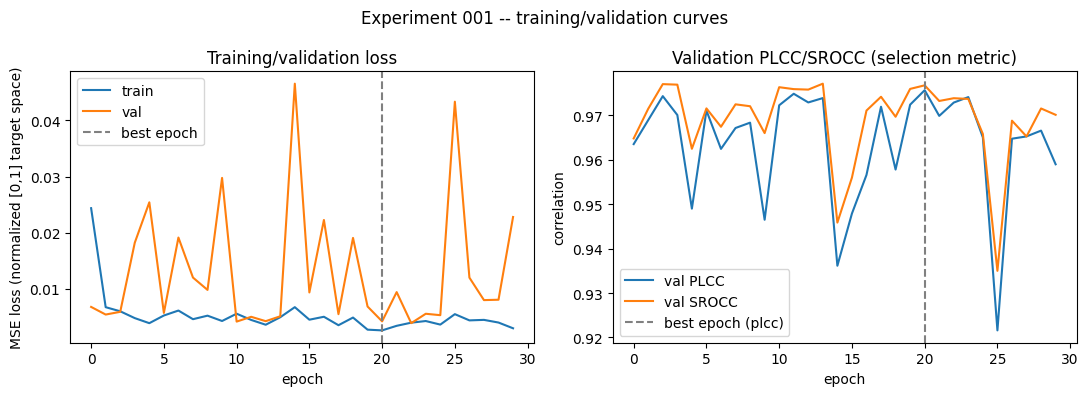

saved training curves to results\figures\001_resnet50_baseline_training_curve.png


In [12]:
if history is not None:
    fig, (ax_loss, ax_corr) = plt.subplots(1, 2, figsize=(11, 4))

    ax_loss.plot(history.train_loss, label="train")
    ax_loss.plot(history.val_loss, label="val")
    ax_loss.axvline(history.best_epoch, color="gray", linestyle="--", label="best epoch")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("MSE loss (normalized [0,1] target space)")
    ax_loss.legend()
    ax_loss.set_title("Training/validation loss")

    ax_corr.plot(history.val_plcc, label="val PLCC")
    ax_corr.plot(history.val_srocc, label="val SROCC")
    ax_corr.axvline(history.best_epoch, color="gray", linestyle="--", label=f"best epoch ({history.selection_metric})")
    ax_corr.set_xlabel("epoch")
    ax_corr.set_ylabel("correlation")
    ax_corr.legend()
    ax_corr.set_title("Validation PLCC/SROCC (selection metric)")

    plt.suptitle("Experiment 001 -- training/validation curves")
    plt.tight_layout()
    figure_path = Path("results/figures/001_resnet50_baseline_training_curve.png")
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved training curves to {figure_path}")
else:
    print("No training history -- RUN_FULL_TRAINING was False in this run.")

## Validation Metrics (post-hoc)

Correlation metrics (PLCC/SROCC/KROCC) on the **validation** split only,
computed AFTER training using the already-existing
`ct_iqa.training.trainer.evaluate_loader` (which already returns
predictions/targets) and `ct_iqa.evaluation.metrics.compute_metrics` --
no change to the training pipeline itself was needed. **This is not a test-set
result** -- the test set remains untouched.

In [13]:
if history is not None:
    from ct_iqa.evaluation.metrics import compute_metrics

    final_val_loss, val_predictions, val_targets = evaluate_loader(model, val_loader, criterion, device=config.device)
    val_metrics = compute_metrics(val_targets.numpy(), val_predictions.numpy())
    print("Validation-split metrics (best-checkpoint model is NOT reloaded here; this reflects the")
    print("model's state at the END of training -- see the checkpoint-reload verification below):")
    for k, v in val_metrics.items():
        print(f"  {k.upper():6s}: {v:.4f}")
else:
    val_metrics = None
    print("Skipped -- RUN_FULL_TRAINING was False in this run.")

Validation-split metrics (best-checkpoint model is NOT reloaded here; this reflects the
model's state at the END of training -- see the checkpoint-reload verification below):
  MSE   : 0.3649
  PLCC  : 0.9590
  SROCC : 0.9701
  KROCC : 0.8697


## Checkpoint & Experiment Artifacts

The checkpoint with the best `config.selection_metric` value
(`"plcc"` by default) is written to
`experiments/001_resnet50_baseline/checkpoint/best.pt` by
`ct_iqa.training.trainer.train` (via `ct_iqa.training.checkpointing`) --
including the optimizer state, epoch, val_loss, resolved config, seed, and
`checkpoint_type` (`"best_<selection_metric>"`) alongside the model
weights, so the checkpoint alone documents what produced it and what it was
selected on. Experiment-generated checkpoints live under `experiments/`,
never under `weights/` -- `weights/pretrained/` is reserved for
externally-sourced pretrained weights only.

Training/validation history and validation metrics are saved as
machine-readable JSON under `experiments/001_resnet50_baseline/` (not
`results/`, since they describe THIS run, not a final cross-experiment
analysis artifact); the training/validation curve figure was already saved
to `results/figures/` above.

In [14]:
experiment_dir = Path(config.experiment_dir)
config.save(experiment_dir / "config.json")
print(f"saved experiment configuration to {experiment_dir / 'config.json'}")

if history is not None:
    history_record = {
        "train_loss": history.train_loss,
        "val_loss": history.val_loss,
        "val_plcc": history.val_plcc,
        "val_srocc": history.val_srocc,
        "selection_metric": history.selection_metric,
        "best_epoch": history.best_epoch,
        "best_selection_value": history.best_selection_value,
        "best_val_loss": history.best_val_loss,
        "final_train_loss": history.train_loss[-1],
        "final_val_loss": history.val_loss[-1],
        "final_val_plcc": history.val_plcc[-1],
        "final_val_srocc": history.val_srocc[-1],
        "epochs_completed": len(history.train_loss),
    }
    (experiment_dir / "history.json").write_text(json.dumps(history_record, indent=2))
    print(f"saved training/validation history to {experiment_dir / 'history.json'}")

    (experiment_dir / "validation_metrics.json").write_text(
        json.dumps({"note": "validation split only -- NOT the held-out test set", "metrics": val_metrics}, indent=2)
    )
    print(f"saved post-hoc validation metrics to {experiment_dir / 'validation_metrics.json'}")

print(f"checkpoint directory: {config.checkpoint_dir}")
print(f"checkpoint present  : {(Path(config.checkpoint_dir) / 'best.pt').exists()}")

saved experiment configuration to experiments\001_resnet50_baseline\config.json
saved training/validation history to experiments\001_resnet50_baseline\history.json
saved post-hoc validation metrics to experiments\001_resnet50_baseline\validation_metrics.json
checkpoint directory: experiments\001_resnet50_baseline\checkpoint
checkpoint present  : True


## Checkpoint Validation

Confirm the saved checkpoint is genuinely usable -- loaded into a **fresh**
model instance, independent of the `model` object trained above, using
only what's on disk.

In [15]:
from ct_iqa.training.checkpointing import best_checkpoint_path, load_checkpoint, load_checkpoint_metadata

checkpoint_path = best_checkpoint_path(config.checkpoint_dir)
assert checkpoint_path.exists(), f"no checkpoint found at {checkpoint_path}"

fresh_model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)  # NOT `model` above
load_checkpoint(fresh_model, config.checkpoint_dir, map_location=config.device)
fresh_model.to(config.device)
fresh_model.eval()

metadata = load_checkpoint_metadata(config.checkpoint_dir, map_location=config.device)
print(f"checkpoint path         : {checkpoint_path}")
print(f"checkpoint epoch        : {metadata.get('epoch')}")
print(f"checkpoint type         : {metadata.get('checkpoint_type')}")
print(f"checkpoint val_loss     : {metadata.get('val_loss')}")
print(f"checkpoint seed         : {metadata.get('seed')}")
print(f"optimizer state saved: {'optimizer_state_dict' in metadata}")

with torch.no_grad():
    check_images, _ = next(iter(val_loader))
    check_output = fresh_model(check_images.to(config.device))

print(f"reload-verification output range: [{check_output.min().item():.4f}, {check_output.max().item():.4f}]")
assert torch.isfinite(check_output).all(), "non-finite output from the reloaded checkpoint"
assert bool((check_output >= 0).all() and (check_output <= 1).all()), "reloaded model's sigmoid output left [0, 1]"
print("CHECKPOINT VALIDATION: loads successfully in a fresh process/model and produces finite [0,1] predictions.")

checkpoint path         : experiments\001_resnet50_baseline\checkpoint\best.pt
checkpoint epoch        : 20
checkpoint type         : best_plcc
checkpoint val_loss     : 0.004226507507264614
checkpoint seed         : 42
optimizer state saved: True


reload-verification output range: [0.0777, 0.9210]
CHECKPOINT VALIDATION: loads successfully in a fresh process/model and produces finite [0,1] predictions.


## Notes

- **RadImageNet weights**: see `weights/pretrained/radimagenet/resnet50/README.md`
  for current provenance/verification status before trusting any backbone
  initialization claim.
- **Smoke test**: verifies forward/backward/optimizer.step() on real data
  before any real training time is spent, then restores pre-smoke-test
  weights so it does not affect the actual run below.
- **Test set**: never touched anywhere in this notebook. TEST SET NOT USED
  FOR MODEL SELECTION.
- Continue in `notebooks/04_evaluation/01_test_set_evaluation.ipynb`, which
  loads this run's checkpoint independently rather than relying on this
  notebook's in-memory state -- that notebook, not this one, is where the
  held-out test set is finally used.